In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
res = pd.read_csv("results.csv")
res

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
0,0,fc16f_00000,0,21189.009739,bald,1,6.006529e+06
1,1,fc16f_00000,1,17152.315504,bald,1,6.006529e+06
2,2,fc16f_00000,2,8313.982032,bald,1,6.006529e+06
3,3,fc16f_00000,3,9006.913807,bald,1,6.006529e+06
4,4,fc16f_00000,4,9494.461573,bald,1,6.006529e+06
...,...,...,...,...,...,...,...
10180,10180,fc16f_00034,286,39041.985700,random,5,1.126295e+07
10181,10181,fc16f_00034,287,38920.787415,random,5,1.126295e+07
10182,10182,fc16f_00034,288,40676.127198,random,5,1.126295e+07
10183,10183,fc16f_00034,289,41413.618922,random,5,1.126295e+07


In [3]:
res[res.strategy=="random"]

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
8730,8730,fc16f_00030,0,21189.009739,random,1,1.187502e+07
8731,8731,fc16f_00030,1,33522.979499,random,1,1.187502e+07
8732,8732,fc16f_00030,2,30960.718292,random,1,1.187502e+07
8733,8733,fc16f_00030,3,29908.269155,random,1,1.187502e+07
8734,8734,fc16f_00030,4,23865.770172,random,1,1.187502e+07
...,...,...,...,...,...,...,...
10180,10180,fc16f_00034,286,39041.985700,random,5,1.126295e+07
10181,10181,fc16f_00034,287,38920.787415,random,5,1.126295e+07
10182,10182,fc16f_00034,288,40676.127198,random,5,1.126295e+07
10183,10183,fc16f_00034,289,41413.618922,random,5,1.126295e+07


In [4]:
aucs = res.drop_duplicates(subset=["strategy","seed"])
agg = aucs.groupby("strategy")["score"]
mean_aucs, std_aucs = agg.mean(), agg.std()
aucs = pd.concat((mean_aucs, std_aucs), axis=1)
aucs.columns = ["avg", "stdv"]
aucs["score"] = aucs.apply(lambda row: f"{row.avg:.2f} ± {row.stdv:.2f}"  ,axis=1)
label_to_auc = dict(zip(aucs.index, aucs["score"]))

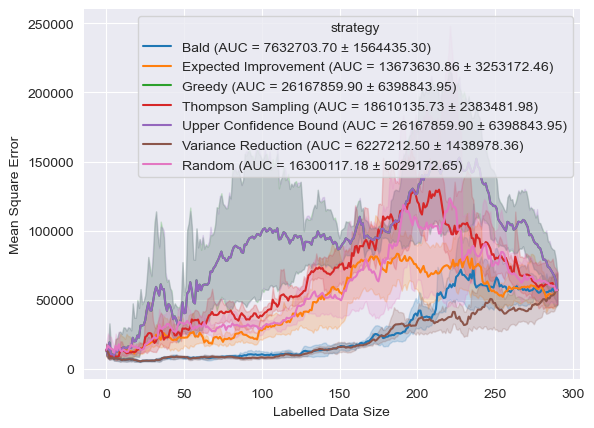

In [8]:
sns.set_style("darkgrid")

sns.lineplot(data=res, x="iteration", y="test_metric", hue="strategy")
plt.ylabel("Mean Square Error")
plt.xlabel("Labelled Data Size")
# _ = plt.xticks(np.arange(0,26), np.arange(0,26)*10 + 20, rotation=45)

ax = plt.gca()
legend = ax.get_legend()
for text in legend.get_texts():
    label = text.get_text()
    new_label = f"{label.replace('_', ' ').title()} (AUC = {label_to_auc[label]})"
    text.set_text(new_label)
    

for spine in ax.spines.values():
    spine.set_visible(False)